# 🌳 Iris Flower Classification using Decision Tree

## Codveda Technologies – Machine Learning Internship

### Intern Information

**Name:** Muhammed Mumeenat

**Internship:** Machine Learning Internship

**Level:** Level 2 (Intermediate)

**Task:** Decision Trees for Classification

**Project:** Iris Flower Classification using Decision Tree

---

# Project Objective

The objective of this project is to build a Decision Tree classifier capable of predicting the species of Iris flowers based on their measurements.

The project includes loading and exploring the dataset, training a Decision Tree model, visualizing the tree structure, preventing overfitting through pruning, and evaluating the model using classification metrics such as Accuracy and F1-Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# 2. Loading the Dataset

The Iris dataset is loaded into a Pandas DataFrame.

Each row represents an Iris flower, while the columns contain measurements used to predict the flower species.

In [2]:
df = pd.read_csv("../datasets/iris.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# 3. Exploring the Dataset

Before training the Decision Tree model, the dataset is explored to understand its size, structure, data types, summary statistics, and missing values.

In [3]:
df.shape

(150, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

### Observation

The dataset contains **150 rows** and **5 columns**.

The first four columns are numerical features representing flower measurements, while the last column (**species**) is the target variable containing the Iris flower species.

There are **no missing values**, so no data cleaning or imputation is required before training the model.

Since the target variable is categorical (string values), it must be encoded into numerical values before training the Decision Tree classifier.

# 4. Encoding the Target Variable

The target variable (**species**) contains text labels.

It is converted into numerical values using Label Encoding so that the Decision Tree algorithm can process it.

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["species"] = encoder.fit_transform(df["species"])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# 5. Feature Selection

The dataset is divided into input features (X) and the target variable (y).

The input features contain flower measurements, while the target variable contains the encoded flower species.

In [9]:
X = df.drop ("species", axis=1)
y = df["species"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (150, 4)
y Shape: (150,)


# 6. Splitting the Dataset

The dataset is divided into training and testing sets.

The training data is used to train the Decision Tree model, while the testing data is used to evaluate its performance.

In [11]:
X_train, X_test, y_train, y_test = train_test_split (
    X,
    y,
    test_size=0.2,
    random_state=42

)
print ("Trainig Samples:", X_train.shape)
print ("Testing Samples:", X_test.shape)

Trainig Samples: (120, 4)
Testing Samples: (30, 4)


# 7. Training the Decision Tree Classifier

A Decision Tree classifier is created and trained using the training dataset.

The model learns a series of decision rules from the flower measurements to classify the Iris species.

In [12]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# 8. Visualizing the Decision Tree

The trained Decision Tree model is visualized to understand how it classifies Iris flower species.

Each node represents a decision based on a feature value, while each leaf node represents the predicted flower species.

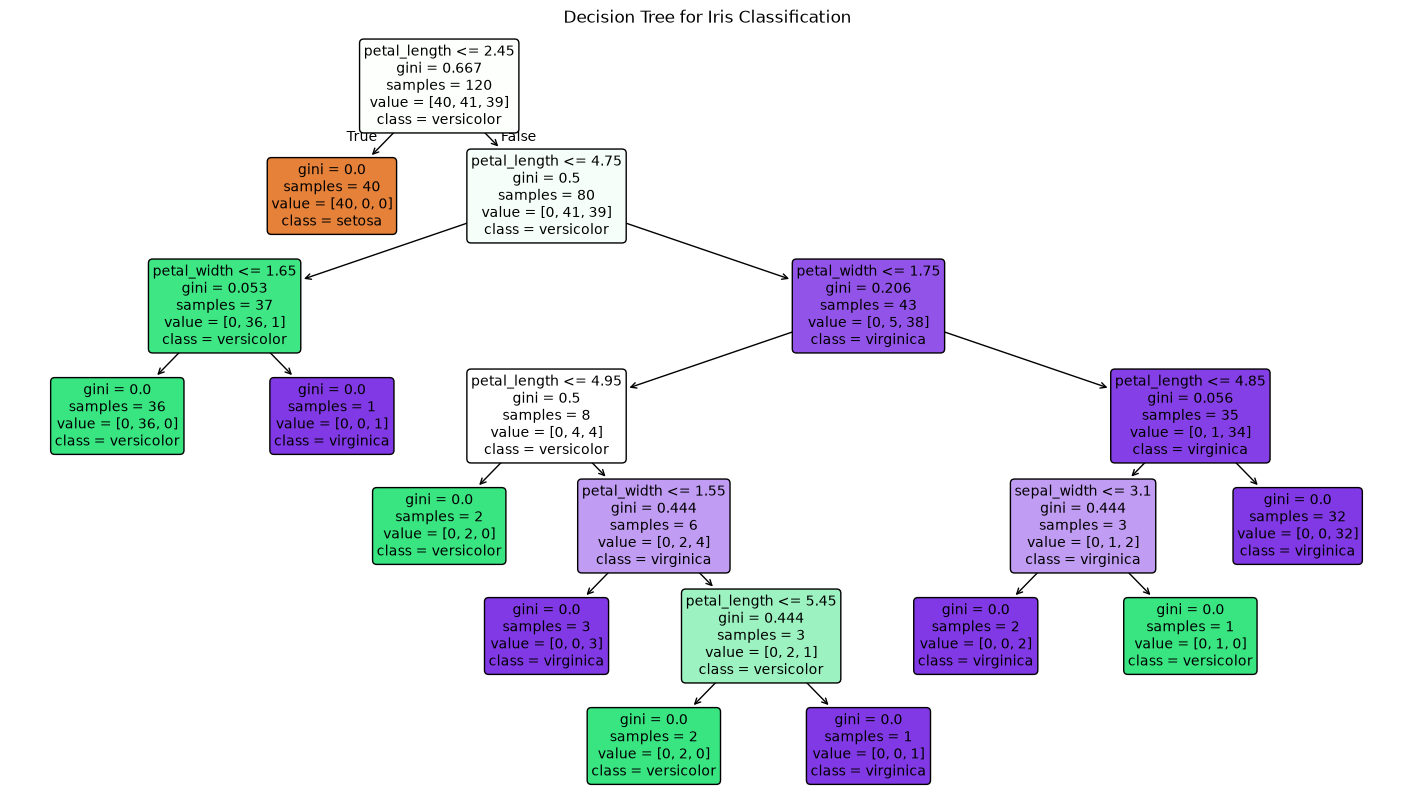

In [13]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Iris Classification")
plt.show()

# 9. Pruning the Decision Tree

Decision Trees can easily overfit the training data if allowed to grow without restriction.

Pruning limits the tree depth, making the model simpler and improving its ability to generalize to unseen data.

In [14]:
pruned_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

pruned_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

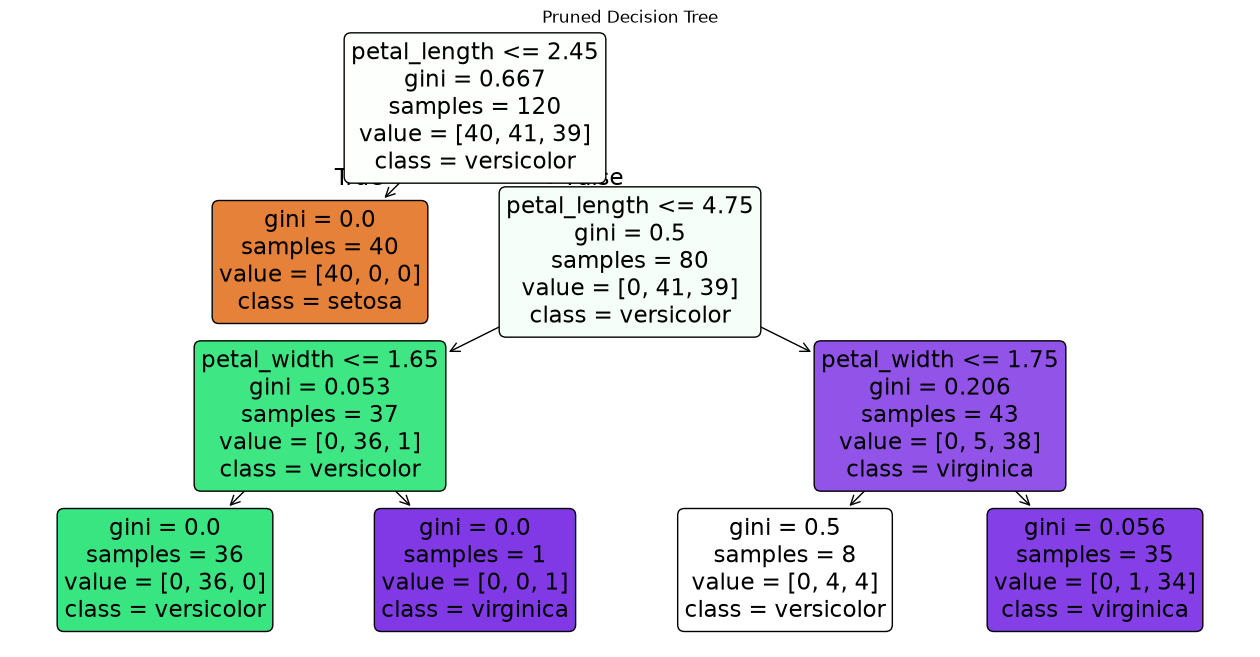

In [15]:
plt.figure(figsize=(16,8))

plot_tree(
    pruned_model,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True,
    rounded=True
)

plt.title("Pruned Decision Tree")
plt.show()

# 10. Making Predictions

The pruned Decision Tree model is used to predict the species of Iris flowers in the testing dataset.

In [16]:
y_pred = pruned_model.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# 11. Model Accuracy

Accuracy measures the proportion of correctly classified Iris flowers.

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


# 12. Classification Report

The classification report summarizes the model's Precision, Recall, F1-Score, and Support for each Iris species.

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 13. F1-Score

The F1-Score combines Precision and Recall into a single metric.

A higher F1-Score indicates better classification performance, especially when considering both false positives and false negatives.

In [19]:
f1 = f1_score(y_test, y_pred, average="weighted")

print("F1 Score:", f1)

F1 Score: 1.0


# 14. Conclusion

A Decision Tree classifier was successfully developed to classify Iris flower species based on their measurements.

The dataset was explored, the target variable was encoded, and the data was split into training and testing sets. A Decision Tree model was trained, visualized, and pruned to improve generalization.

The final model achieved:

- **Accuracy:** 100%
- **Precision:** 100%
- **Recall:** 100%
- **F1-Score:** 100%

These results indicate that the Decision Tree classifier accurately distinguished between all three Iris flower species on the test dataset.

This project demonstrates the effectiveness, interpretability, and simplicity of Decision Trees for classification tasks.